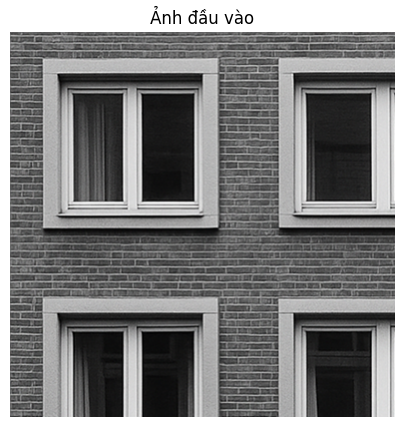

Số điểm đặc trưng SIFT: 630
Kích thước descriptor: (630, 128)


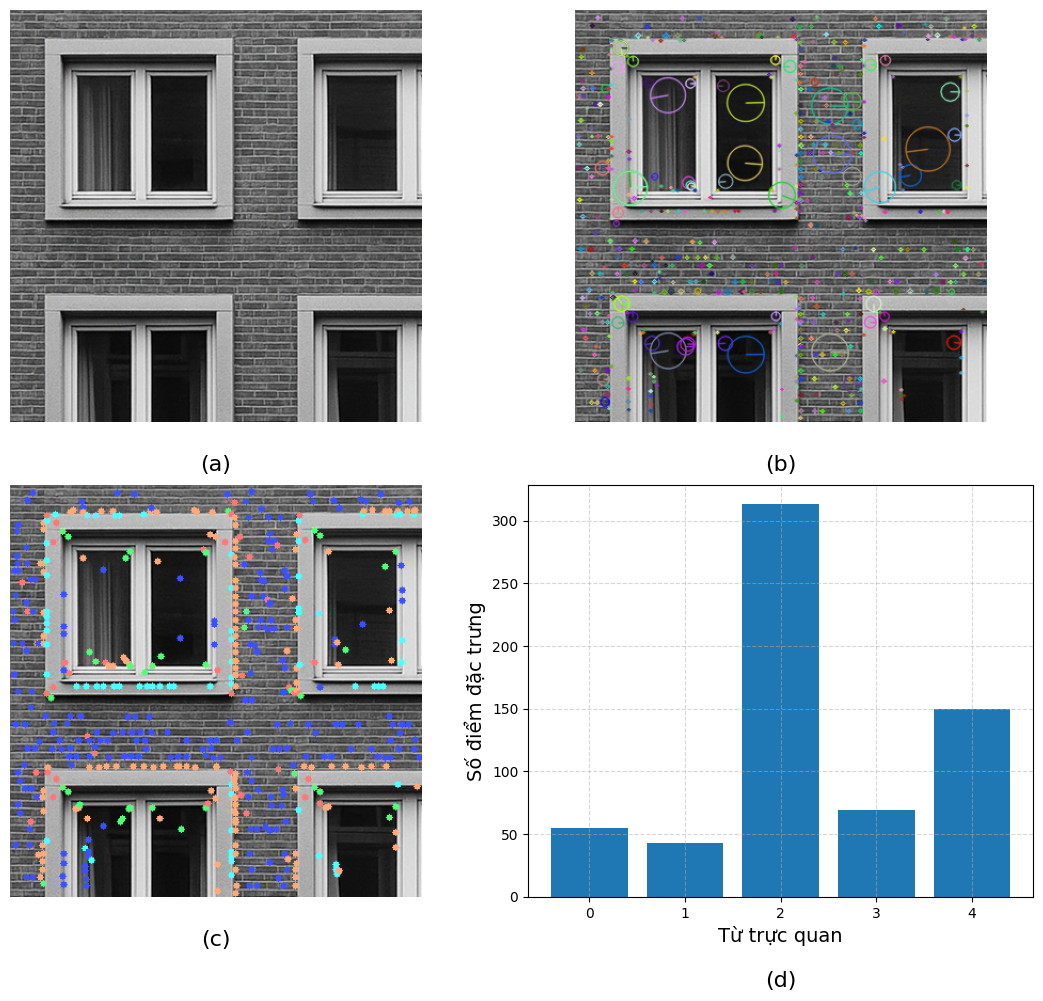


Từ điển trực quan W có kích thước: (5, 128)
Histogram BoVW: [ 55  43 313  69 150]
Histogram BoVW chuẩn hóa: [0.08730159 0.06825397 0.4968254  0.10952381 0.23809524]

Kiểm tra kết quả:
- Đọc ảnh thành công.
- Trích rút SIFT thành công.
- Xây dựng từ điển trực quan thành công.
- Lượng tử hóa descriptor thành công.
- Histogram BoVW hợp lệ.


In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: BIỂU DIỄN ẢNH BẰNG BAG OF VISUAL WORDS
# Chương/Mục liên quan: Chương 5 - Đặc trưng thủ công và biểu diễn ảnh
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa quy trình biểu diễn ảnh bằng mô hình Bag of Visual Words.
# - Giúp người học quan sát các điểm đặc trưng SIFT, quá trình lượng tử hóa
#   đặc trưng cục bộ và histogram BoVW.
# - Liên hệ code với các bước: trích rút đặc trưng, xây dựng từ điển trực quan,
#   lượng tử hóa đặc trưng và biểu diễn ảnh bằng histogram.

# Sau khi chạy code, người học cần:
# 1. Hiểu được cách ảnh được biểu diễn bởi tập descriptor SIFT cục bộ.
# 2. Hiểu được vai trò của k-means trong xây dựng từ điển trực quan.
# 3. Quan sát được histogram BoVW biểu diễn phân bố các từ trực quan trong ảnh.

# Input:
# - Dữ liệu đầu vào: ảnh windows.png từ GitHub.
# - Kiểu dữ liệu: ảnh màu, sau đó chuyển sang ảnh xám để trích rút SIFT.

# Output:
# - Ảnh gốc.
# - Ảnh có các điểm đặc trưng SIFT.
# - Ảnh có các điểm đặc trưng đã lượng tử hóa theo từ trực quan.
# - Histogram Bag of Visual Words.

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với công thức hoặc thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen
from sklearn.cluster import KMeans

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

image_url = "https://github.com/lthavnu/cv-book/raw/main/images/windows.png"

# Số từ trực quan trong từ điển BoVW
k = 5


def read_image_from_url(url, flag=cv2.IMREAD_COLOR):
    resp = urlopen(url)
    img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    return cv2.imdecode(img, flag)


I_bgr = read_image_from_url(image_url, cv2.IMREAD_COLOR)

if I_bgr is None:
    raise ValueError("Không đọc được ảnh từ URL.")

I_gray = cv2.cvtColor(I_bgr, cv2.COLOR_BGR2GRAY)
I_rgb = cv2.cvtColor(I_bgr, cv2.COLOR_BGR2RGB)

# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

plt.figure(figsize=(5, 5))
plt.imshow(I_rgb)
plt.axis("off")
plt.title("Ảnh đầu vào")
plt.show()

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================


def extract_sift_features(I_gray):
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(I_gray, None)
    return keypoints, descriptors


def build_visual_dictionary(F_local, k=5, random_state=0):
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    kmeans.fit(F_local)

    W = kmeans.cluster_centers_

    return kmeans, W


def quantize_features(descriptors, kmeans):
    word_ids = kmeans.predict(descriptors)
    return word_ids


def compute_bovw_histogram(word_ids, k):
    h = np.bincount(word_ids, minlength=k)
    return h


def draw_sift_keypoints(I_bgr, keypoints):
    I_draw = cv2.drawKeypoints(
        I_bgr,
        keypoints,
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    I_draw = cv2.cvtColor(I_draw, cv2.COLOR_BGR2RGB)

    return I_draw


def draw_quantized_keypoints(I_gray, keypoints, word_ids, k):
    I_vis = cv2.cvtColor(I_gray, cv2.COLOR_GRAY2RGB)

    color_map = np.array(
        [
            [255, 120, 120],
            [80, 255, 120],
            [60, 80, 255],
            [80, 255, 255],
            [255, 170, 120],
        ],
        dtype=np.uint8
    )

    for kp, wid in zip(keypoints, word_ids):
        x, y = kp.pt
        x, y = int(round(x)), int(round(y))

        color = tuple(int(c) for c in color_map[wid % len(color_map)])
        cv2.circle(I_vis, (x, y), radius=3, color=color, thickness=-1)

    return I_vis


# Bước 1: Trích rút đặc trưng SIFT từ ảnh xám
keypoints, descriptors = extract_sift_features(I_gray)

if descriptors is None or len(descriptors) < k:
    raise ValueError(
        f"Số descriptor SIFT ({0 if descriptors is None else len(descriptors)}) "
        f"không đủ để phân cụm thành {k} từ trực quan."
    )

print(f"Số điểm đặc trưng SIFT: {len(keypoints)}")
print(f"Kích thước descriptor: {descriptors.shape}")

# F_local = {f_i}_{i=1}^m
F_local = descriptors.astype(np.float32)

# Bước 2: Xây dựng từ điển trực quan W = {w_i}_{i=1}^k bằng k-means
kmeans, W = build_visual_dictionary(F_local, k=k, random_state=0)

# Bước 3: Lượng tử hóa mỗi descriptor về từ trực quan gần nhất
# Công thức minh họa: c_W(f) = arg min_i ||f - w_i||
word_ids = quantize_features(F_local, kmeans)

# Bước 4: Tính histogram BoVW
h_bovw = compute_bovw_histogram(word_ids, k)

# Bước 5: Chuẩn hóa histogram BoVW
h_bovw_norm = h_bovw / np.sum(h_bovw)

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

I_sift = draw_sift_keypoints(I_bgr, keypoints)
I_quantized = draw_quantized_keypoints(I_gray, keypoints, word_ids, k)

fig, axes = plt.subplots(2, 2, figsize=(11, 10))

axes[0, 0].imshow(I_rgb)
axes[0, 0].axis("off")
axes[0, 0].text(
    0.5, -0.08, "(a)",
    transform=axes[0, 0].transAxes,
    ha="center",
    va="top",
    fontsize=16
)

axes[0, 1].imshow(I_sift)
axes[0, 1].axis("off")
axes[0, 1].text(
    0.5, -0.08, "(b)",
    transform=axes[0, 1].transAxes,
    ha="center",
    va="top",
    fontsize=16
)

axes[1, 0].imshow(I_quantized)
axes[1, 0].axis("off")
axes[1, 0].text(
    0.5, -0.08, "(c)",
    transform=axes[1, 0].transAxes,
    ha="center",
    va="top",
    fontsize=16
)

axes[1, 1].bar(np.arange(k), h_bovw)
axes[1, 1].set_xlabel("Từ trực quan", fontsize=14)
axes[1, 1].set_ylabel("Số điểm đặc trưng", fontsize=14)
axes[1, 1].set_xticks(np.arange(k))
axes[1, 1].grid(True, linestyle="--", alpha=0.5)
axes[1, 1].text(
    0.5, -0.18, "(d)",
    transform=axes[1, 1].transAxes,
    ha="center",
    va="top",
    fontsize=16
)

plt.tight_layout()
plt.show()

print("\nTừ điển trực quan W có kích thước:", W.shape)
print("Histogram BoVW:", h_bovw)
print("Histogram BoVW chuẩn hóa:", h_bovw_norm)

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

assert I_bgr is not None, "Ảnh đầu vào chưa được đọc thành công."
assert len(keypoints) > 0, "Không phát hiện được điểm đặc trưng SIFT."
assert descriptors.shape[1] == 128, "Descriptor SIFT phải có 128 chiều."
assert W.shape == (k, 128), "Từ điển trực quan phải có kích thước (k, 128)."
assert len(word_ids) == len(descriptors), "Mỗi descriptor phải được gán một từ trực quan."
assert np.sum(h_bovw) == len(descriptors), "Tổng histogram phải bằng số descriptor."

print("\nKiểm tra kết quả:")
print("- Đọc ảnh thành công.")
print("- Trích rút SIFT thành công.")
print("- Xây dựng từ điển trực quan thành công.")
print("- Lượng tử hóa descriptor thành công.")
print("- Histogram BoVW hợp lệ.")

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# Gợi ý 1:
# - Thay đổi k = 5 thành k = 10 hoặc k = 20 để quan sát histogram BoVW chi tiết hơn.

# Gợi ý 2:
# - Thay đổi image_url sang một ảnh khác để so sánh histogram BoVW giữa các ảnh.

# Gợi ý 3:
# - Thay đổi random_state trong KMeans để quan sát ảnh hưởng của khởi tạo cụm
#   đến từ điển trực quan và histogram BoVW.